In [ ]:
!pip install vmdpy -q
import numpy as np
import matplotlib.pyplot as plt
from vmdpy import VMD

np.random.seed(0)
fs = 100
T_dur = 2
t = np.linspace(0, T_dur, fs*T_dur)
half = len(t)//2
signal = np.concatenate([
    np.sin(2*np.pi*2*t[:half]),
    np.sin(2*np.pi*8*t[half:])
]) + 0.1*np.random.randn(len(t))

alpha, tau_vmd, K, DC, init, tol = 2000, 0.0, 4, 0, 1, 1e-6
u, u_hat, omega = VMD(signal, alpha, tau_vmd, K, DC, init, tol)
print("VMD çıktısı shape:", u.shape)   # (K, T)

VMD çıktısı shape: (4, 200)


In [ ]:
def multi_grained_windows(mode_signal, window_size, stride):
    T = len(mode_signal)
    N_tau = (T - window_size)//stride + 1
    windows = np.array([
        mode_signal[i*stride : i*stride + window_size]
        for i in range(N_tau)
    ])
    return windows   # shape: (N_tau, window_size)

# Sentetik sinyalimiz T=200; makaledeki 100/200/400 çok büyük kalacağı için
# öğrenme amaçlı ORANTILI küçültülmüş pencere boyutları kullanıyoruz: 20/40/80
mode0 = u[0]   # ilk modu örnek alalım
tau_test = 20
s_test = tau_test//2
windows = multi_grained_windows(mode0, tau_test, s_test)
print(f"τ={tau_test}, s={s_test} için pencere sayısı (N_τ): {windows.shape[0]}")
print("Beklenen (formülle):", (len(mode0)-tau_test)//s_test + 1)

τ=20, s=10 için pencere sayısı (N_τ): 19
Beklenen (formülle): 19


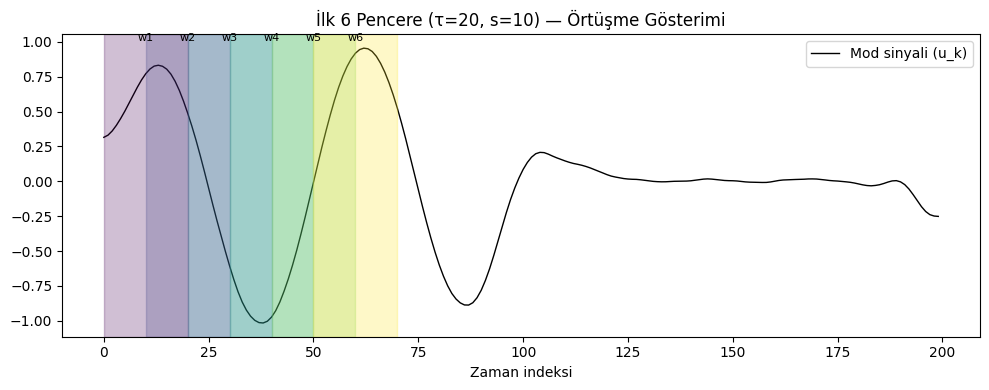

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(mode0, color='black', linewidth=1, label='Mod sinyali (u_k)', zorder=1)

colors = plt.cm.viridis(np.linspace(0,1,6))   # ilk 6 pencereyi gösterelim
for i in range(6):
    start = i*s_test
    ax.axvspan(start, start+tau_test, color=colors[i], alpha=0.25)
    ax.text(start+tau_test/2, mode0.max()*1.05, f"w{i+1}", ha='center', fontsize=8)

ax.set_title(f"İlk 6 Pencere (τ={tau_test}, s={s_test}) — Örtüşme Gösterimi")
ax.set_xlabel("Zaman indeksi")
ax.legend()
plt.tight_layout(); plt.show()

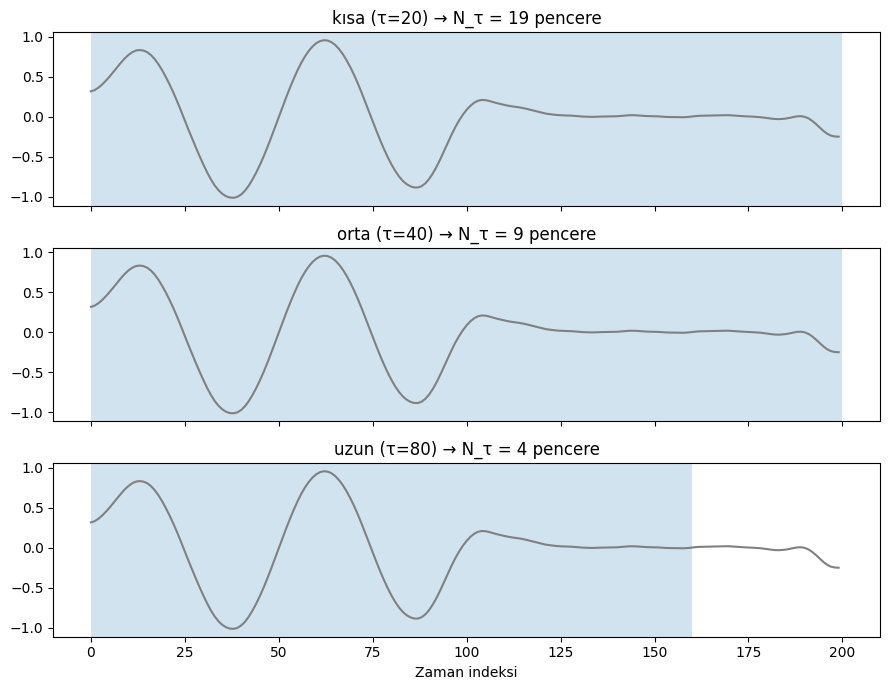

In [ ]:
window_sizes = {"kısa (τ=20)": 20, "orta (τ=40)": 40, "uzun (τ=80)": 80}

fig, axes = plt.subplots(len(window_sizes), 1, figsize=(9, 7), sharex=True)
for ax, (label, tau_v) in zip(axes, window_sizes.items()):
    s_v = tau_v//2
    n_windows = (len(mode0)-tau_v)//s_v + 1
    ax.plot(mode0, color='gray')
    for i in range(0, n_windows, 2):   # okunabilirlik için her 2 pencereden birini göster
        start = i*s_v
        ax.axvspan(start, start+tau_v, alpha=0.2)
    ax.set_title(f"{label} → N_τ = {n_windows} pencere")
axes[-1].set_xlabel("Zaman indeksi")
plt.tight_layout(); plt.show()

In [ ]:
tau_final = 20
s_final = tau_final//2
all_mode_windows = []
for k in range(u.shape[0]):
    w = multi_grained_windows(u[k], tau_final, s_final)   # (N_tau, tau)
    all_mode_windows.append(w)

all_mode_windows = np.stack(all_mode_windows)   # (K, N_tau, tau)
print("Tüm modlar için pencerelenmiş veri shape (K, N_τ, τ):", all_mode_windows.shape)

Tüm modlar için pencerelenmiş veri shape (K, N_τ, τ): (4, 19, 20)
